In [1]:
import sys
!{sys.executable} -m pip install pandas scikit-learn vaderSentiment fastapi uvicorn wordcloud matplotlib seaborn nltk

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK data (only runs once)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words("english"))

# ── Load dataset ──
# Place complaints_processed.csv in the SAME folder as this notebook
df = pd.read_csv(r"C:\Users\parth\Downloads\complaints_processed.csv\complaints_processed.csv")

# ── Clean text with Lemmatization ──
# Lemmatization converts words to their root form: "running" -> "run"
def clean_text(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r"http\S+", "", text)             # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)        # remove special chars
    words = text.split()
    # remove stopwords and lemmatize each word
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["narrative"].apply(clean_text)

print(df.head())

   Unnamed: 0           product  \
0           0       credit_card   
1           1       credit_card   
2           2    retail_banking   
3           3  credit_reporting   
4           4  credit_reporting   

                                           narrative  \
0  purchase order day shipping amount receive pro...   
1  forwarded message date tue subject please inve...   
2  forwarded message cc sent friday pdt subject f...   
3  payment history missing credit report speciali...   
4  payment history missing credit report made mis...   

                                          clean_text  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message sent friday pdt subject fina...  
3  payment history missing credit report speciali...  
4  payment history missing credit report made mis...  


In [4]:
print(df.shape)
print(df['product'].value_counts())

(162421, 4)
product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64


In [5]:
print(df.isnull().sum())

Unnamed: 0     0
product        0
narrative     10
clean_text     0
dtype: int64


In [6]:
df = df.dropna()

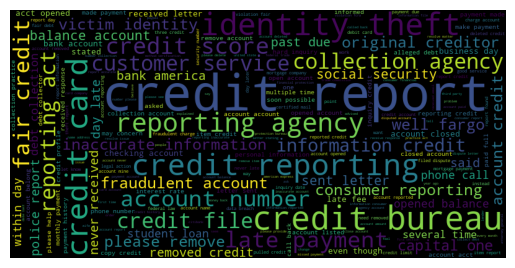

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,2), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

print(vectorizer.get_feature_names_out())

['account' 'company' 'credit' 'credit report' 'information' 'payment'
 'report' 'reporting' 'time' 'would']


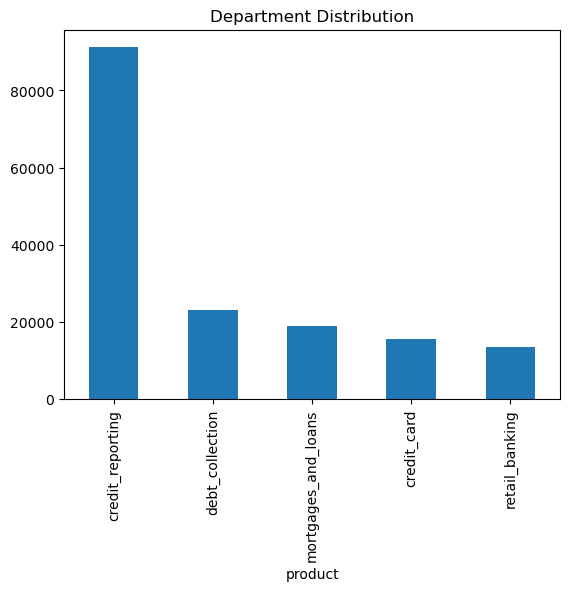

In [9]:
import matplotlib.pyplot as plt

df['product'].value_counts().plot(kind='bar')
plt.title("Department Distribution")
plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['product'])

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model (fixed convergence issue)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [13]:
# Cross-Validation
# Instead of trusting one train/test split, we test the model 5 times
# on different parts of the data to confirm it generalises well.
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Cross-Validation Accuracy per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std  Accuracy : {cv_scores.std():.4f}")

Cross-Validation Accuracy per fold:
  Fold 1: 0.8708
  Fold 2: 0.8714
  Fold 3: 0.8715
  Fold 4: 0.8736
  Fold 5: 0.8708
Mean Accuracy : 0.8716
Std  Accuracy : 0.0010


In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [15]:
df.head()

,Unnamed: 0,product,narrative,clean_text,label
0,0,credit_card,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...,0
1,1,credit_card,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...,0
2,2,retail_banking,forwarded message cc sent friday pdt subject f...,forwarded message sent friday pdt subject fina...,4
3,3,credit_reporting,payment history missing credit report speciali...,payment history missing credit report speciali...,1
4,4,credit_reporting,payment history missing credit report made mis...,payment history missing credit report made mis...,1


In [16]:
def get_priority(text, sentiment):
    text = text.lower()
    
    if "urgent" in text or "immediately" in text:
        return "Critical"
    
    if sentiment == "Negative":
        return "High"
    elif sentiment == "Positive":
        return "Low"
    else:
        return "Medium"

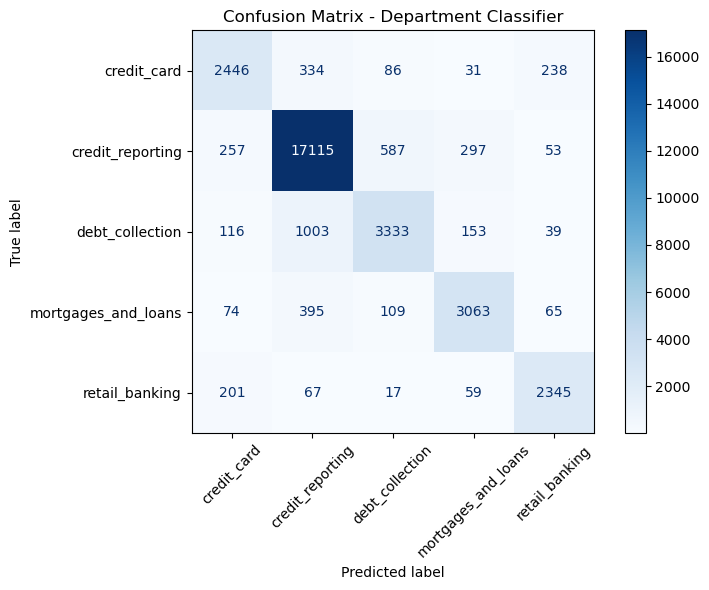

                     precision    recall  f1-score   support

        credit_card       0.79      0.78      0.79      3135
   credit_reporting       0.90      0.93      0.92     18309
    debt_collection       0.81      0.72      0.76      4644
mortgages_and_loans       0.85      0.83      0.84      3706
     retail_banking       0.86      0.87      0.86      2689

           accuracy                           0.87     32483
          macro avg       0.84      0.83      0.83     32483
       weighted avg       0.87      0.87      0.87     32483



In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

# Confusion Matrix with department names
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Department Classifier")
plt.tight_layout()
plt.show()

# Full report
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [18]:
import pickle

pickle.dump(model, open('department_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [19]:
def predict_complaint(text):
    text_clean = clean_text(text)
    text_tfidf = tfidf.transform([text_clean])
    
    pred = model.predict(text_tfidf)
    department = le.inverse_transform(pred)[0]
    
    sentiment = get_sentiment(text)
    priority = get_priority(text, sentiment)

    return {
        "department": department,
        "sentiment": sentiment,
        "priority": priority
    }

print(predict_complaint("I cannot use my credit card"))

{'department': 'credit_card', 'sentiment': 'Negative', 'priority': 'High'}


In [22]:
# pip install fastapi uvicorn vaderSentiment
# python -m uvicorn app:app --reload

In [20]:
df.head()

,Unnamed: 0,product,narrative,clean_text,label
0,0,credit_card,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...,0
1,1,credit_card,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...,0
2,2,retail_banking,forwarded message cc sent friday pdt subject f...,forwarded message sent friday pdt subject fina...,4
3,3,credit_reporting,payment history missing credit report speciali...,payment history missing credit report speciali...,1
4,4,credit_reporting,payment history missing credit report made mis...,payment history missing credit report made mis...,1


In [ ]:
http://127.0.0.1:8000/docs#/default/predict_predict_get